# Domain Adaptation with MMD: MNIST → USPS

This notebook trains a simple CNN classifier on **MNIST** (source) and evaluates on **USPS** (target).
We then **add an MMD loss** to align feature distributions and show improved target performance.

In [1]:
import os, math, random
from typing import Tuple
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from torchvision import datasets, transforms
from tqdm.auto import tqdm

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

device

device(type='cuda')

## 1) Data: MNIST (source) and USPS (target)

We use torchvision datasets. USPS images are resized to 28×28 and both datasets are scaled to [0,1].

In [2]:
mnist_tf = transforms.ToTensor()
usps_tf  = transforms.Compose([transforms.Resize((28,28)), transforms.ToTensor()])

data_root = "./data"
mnist_train = datasets.MNIST(root=data_root, train=True,  transform=mnist_tf, download=True)
mnist_test  = datasets.MNIST(root=data_root, train=False, transform=mnist_tf, download=True)

# --- USPS with fallback ---
def load_usps_with_fallback(root, train, transform):
    # 1) try torchvision downloader
    try:
        ds = datasets.USPS(root=root, train=train, transform=transform, download=True)
        _ = ds[0]  # touch to ensure files present
        return ds
    except Exception as e:
        print(f"[USPS] torchvision download failed: {e}")

    # 2) fallback to OpenML (needs internet, but different host)
    try:
        from sklearn.datasets import fetch_openml
        print("[USPS] Trying OpenML fallback…")
        openml = fetch_openml("usps", version=2, as_frame=False, data_home=root)
        X = openml["data"]  # shape (9298, 256), values in [-1,1]
        y = openml["target"].astype(np.int64)

        # Split like torchvision’s train/test sizes (7291 train / 2007 test)
        n_train = 7291
        if train:
            X, y = X[:n_train], y[:n_train]
        else:
            X, y = X[n_train:], y[n_train:]

        class USPSOpenML(Dataset):
            def __init__(self, X, y, transform):
                self.X = X.astype(np.float32).reshape(-1, 16, 16)  # [-1,1]
                self.y = y
                self.transform = transform
            def __len__(self):
                return len(self.y)
            def __getitem__(self, idx):
                img = self.X[idx]
                # map from [-1,1] -> [0,1] for display parity with MNIST
                img = (img + 1.0) / 2.0
                img = Image.fromarray((img * 255).astype(np.uint8), mode="L")
                if self.transform is not None:
                    img = self.transform(img)
                return img, int(self.y[idx])

        return USPSOpenML(X, y, transform)
    except Exception as e:
        print(f"[USPS] OpenML fallback also failed: {e}")
        raise RuntimeError(
            "USPS could not be downloaded. If you are offline, manually place USPS files "
            "under ./data/USPS/ and set download=False, or run with internet access."
        )

usps_train = load_usps_with_fallback(data_root, train=True,  transform=usps_tf)
usps_test  = load_usps_with_fallback(data_root, train=False, transform=usps_tf)

len(mnist_train), len(mnist_test), len(usps_train), len(usps_test)

(60000, 10000, 7291, 2007)

## 2) Model: feature extractor + classifier

In [3]:
class FeatCNN(nn.Module):
    def __init__(self, feat_dim: int = 128):
        super().__init__()
        self.cnn = nn.Sequential(
             nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
             nn.ReLU(),
             nn.MaxPool2d(kernel_size=2, stride=2, padding=0),

             nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
             nn.ReLU(),
             nn.MaxPool2d(kernel_size=2, stride=2, padding=0),

             nn.Flatten(),
             nn.Linear(64 * (28//4) * (28//4), feat_dim), 
             nn.ReLU()
         )
    def forward(self, x):
         #To-do
        return self.cnn(x)

class Classifier(nn.Module):
    def __init__(self, feat_dim: int = 128, num_classes: int = 10):
        #To-do
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(feat_dim, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    def forward(self, z):
         #To-do
         return self.fc(z)

class Net(nn.Module):
    def __init__(self, feat_dim: int = 128, num_classes: int = 10):
        super().__init__()
        self.feat = FeatCNN(feat_dim)
        self.cls  = Classifier(feat_dim, num_classes)
    def forward(self, x):
        z = self.feat(x)
        y = self.cls(z)
        return y, z

In [4]:
# Instantiate model
net = Net().to(device)

## 3) Dataloaders

In [5]:
BATCH = 128
mnist_train_loader = DataLoader(mnist_train, batch_size=BATCH, shuffle=True, num_workers=0, pin_memory=True)
mnist_test_loader  = DataLoader(mnist_test,  batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=True)
usps_train_loader  = DataLoader(usps_train,  batch_size=BATCH, shuffle=True, num_workers=0, pin_memory=True)
usps_test_loader   = DataLoader(usps_test,   batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=True)

## 4) Evaluation utilities

> Question: Code an evaluation mmethod based on predicting the correct digits from a given image

In [6]:
@torch.no_grad()
def evaluate(model: Net, loader: DataLoader, desc: str = "Eval"):
    # To-do
    model.eval()
    predicts = []
    label = []
    for x, y in tqdm(loader, desc=desc):
        x, y = x.to(device), y.to(device)
        predict, _ = model(x)
        predicts.append(predict)
        label.append(y)
    acc = torch.cat(predicts).argmax(dim=1).eq(torch.cat(label)).float().mean().item()
    print(f"{desc} accuracy: {acc}")
    return acc

## 5) Baseline: train on MNIST only

In [7]:
def train_ce_on_mnist(epochs=5, lr=1e-3):
    # To-do
    model = Net().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    ce  = nn.CrossEntropyLoss()

    for ep in range(1, epochs+1):
        model.train()
        for x, y in tqdm(mnist_train_loader, desc=f"Epoch {ep}"):
            x, y = x.to(device), y.to(device)
            predict,_ = model(x)
            loss = ce(predict,y)
            opt.zero_grad()
            loss.backward()
            opt.step()
        evaluate(model, mnist_test_loader, desc="MNIST→MNIST")
        evaluate(model, usps_test_loader,  desc="MNIST→USPS")
    return model

baseline = train_ce_on_mnist(epochs=10, lr=1e-3)

Epoch 1:   0%|          | 0/469 [00:00<?, ?it/s]

MNIST→MNIST:   0%|          | 0/79 [00:00<?, ?it/s]

MNIST→MNIST accuracy: 0.9788999557495117


MNIST→USPS:   0%|          | 0/16 [00:00<?, ?it/s]

MNIST→USPS accuracy: 0.7528650164604187


...

Epoch 10:   0%|          | 0/469 [00:00<?, ?it/s]

MNIST→MNIST:   0%|          | 0/79 [00:00<?, ?it/s]

MNIST→MNIST accuracy: 0.9898999929428101


MNIST→USPS:   0%|          | 0/16 [00:00<?, ?it/s]

MNIST→USPS accuracy: 0.7468859553337097


## 6) MMD: RBF kernel and unbiased estimator

In [8]:
# Code a mixture of RBF Kernels with different bandwidths
def rbf_kernel(x: torch.Tensor, y: torch.Tensor, sigmas=(2, 5, 10)) -> torch.Tensor:
    #To-do
    # Compute pairwise squared distances ||x_i - y_j||^2
    diff = x[:, None, :] - y[None, :, :]     # shape (n, m, d)
    dist_sq = torch.sum(diff ** 2, dim=-1)   # shape (n, m)

    # Compute mixture of RBFs
    k = torch.zeros_like(dist_sq)
    for s in sigmas:
        k += torch.exp(-dist_sq / (2 * s ** 2))
    k /= len(sigmas)  # average over sigmas

    return k

#Code the unbiased MMD estimate
def mmd_unbiased(x: torch.Tensor, y: torch.Tensor, sigmas=(2,5,10)) -> torch.Tensor:
    #To-do

    n, m = x.size(0), y.size(0)
    k_xx = rbf_kernel(x, x, sigmas)
    k_yy = rbf_kernel(y, y, sigmas)
    k_xy = rbf_kernel(x, y, sigmas)

    # remove diagonals
    k_xx_no_diag = k_xx.clone()
    k_yy_no_diag = k_yy.clone()
    k_xx_no_diag.fill_diagonal_(0)
    k_yy_no_diag.fill_diagonal_(0)

    # unbiased MMD^2
    mmd2 = (
        (torch.sum(k_xx_no_diag) / (n * (n - 1)))
        + (torch.sum(k_yy_no_diag) / (m * (m - 1)))
        - (2 * torch.sum(k_xy) / (n * m))
    )
    return k_xx_no_diag, k_yy_no_diag, k_xy, mmd2


> Question: Compare the unbiased and biased estimator MMD. Hint: Plot the matrix with the same scale

In [9]:
from matplotlib.pyplot import imshow
import matplotlib.pyplot as plt

Unbiased MMD²: 0.0912
Biased MMD²:   0.1025


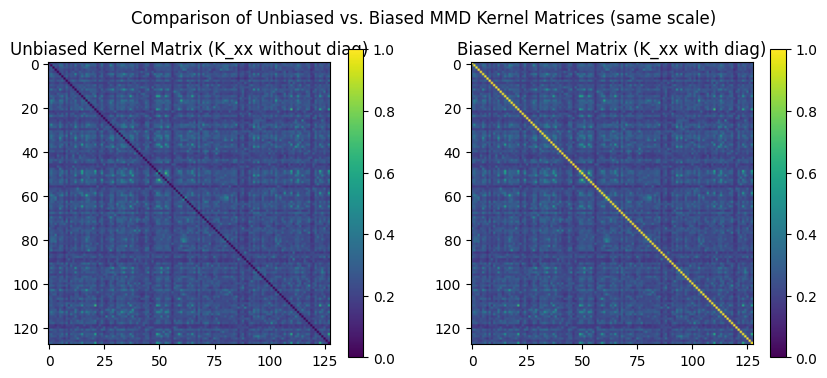

In [10]:
# Plot the matrix to compare unbaiased and biased estimator MMD with the same scale
def mmd_biased(x: torch.Tensor, y: torch.Tensor, sigmas=(2,5,10)) -> torch.Tensor:
    n, m = x.size(0), y.size(0)
    k_xx = rbf_kernel(x, x, sigmas)
    k_yy = rbf_kernel(y, y, sigmas)
    k_xy = rbf_kernel(x, y, sigmas)

    # biased MMD^2 includes diagonal
    mmd2 = (
        (torch.sum(k_xx) / (n * n))
        + (torch.sum(k_yy) / (m * m))
        - (2 * torch.sum(k_xy) / (n * m))
    )
    return k_xx, k_yy, k_xy, mmd2

# --- Load one batch of MNIST and USPS ---
x, _ = next(iter(mnist_train_loader))
y, _ = next(iter(usps_train_loader))
x = x.view(x.size(0), -1)
y = y.view(y.size(0), -1)

# --- Compute matrices ---
kxx_u, kyy_u, kxy_u, mmd_u = mmd_unbiased(x, y)
kxx_b, kyy_b, kxy_b, mmd_b = mmd_biased(x, y)

print(f"Unbiased MMD²: {mmd_u.item():.4f}")
print(f"Biased MMD²:   {mmd_b.item():.4f}")

# --- Plot matrices with same color scale ---
vmin = min(kxx_u.min(), kxx_b.min())
vmax = max(kxx_u.max(), kxx_b.max())

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(kxx_u.detach().numpy(), cmap="viridis", vmin=vmin, vmax=vmax)
plt.title("Unbiased Kernel Matrix (K_xx without diag)")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(kxx_b.detach().numpy(), cmap="viridis", vmin=vmin, vmax=vmax)
plt.title("Biased Kernel Matrix (K_xx with diag)")
plt.colorbar()

plt.suptitle("Comparison of Unbiased vs. Biased MMD Kernel Matrices (same scale)")
plt.show()


## 7) Domain adaptation with MMD

In [11]:
def train_mmd_adapt(epochs=10, lr=1e-3, lam=1.0, sigmas=(2,5,10)):
    model = Net().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    ce  = nn.CrossEntropyLoss()

    src_iter = iter(mnist_train_loader)
    tgt_iter = iter(usps_train_loader)

    for ep in range(1, epochs+1):
        model.train()
        for batch_idx in tqdm(range(len(mnist_train_loader)), desc=f"Epoch {ep}"):
            # Get batches from both source and target loaders
            try:
                x_src, y_src = next(src_iter)
            except StopIteration:
                src_iter = iter(mnist_train_loader)
                x_src, y_src = next(src_iter)

            try:
                x_tgt, _ = next(tgt_iter)
            except StopIteration:
                tgt_iter = iter(usps_train_loader)
                x_tgt, _ = next(tgt_iter)

            x_src, y_src = x_src.to(device), y_src.to(device)
            x_tgt = x_tgt.to(device)

            # Forward pass
            y_pred_src, z_src = model(x_src)
            _, z_tgt = model(x_tgt)

            # Compute classification loss on source domain
            ce_loss = ce(y_pred_src, y_src)

            # Compute MMD loss between source and target features
            _, _, _, mmd_loss = mmd_unbiased(z_src, z_tgt, sigmas)

            # Total loss
            loss = ce_loss + lam * mmd_loss

            # Backward pass and optimization
            opt.zero_grad()
            loss.backward()
            opt.step()


        evaluate(model, mnist_test_loader, desc="Adapted MNIST→MNIST")
        evaluate(model, usps_test_loader,  desc="Adapted MNIST→USPS")
    return model

adapted = train_mmd_adapt(epochs=10, lr=1e-3, lam=1.0, sigmas=(2,5,10))

Epoch 1:   0%|          | 0/469 [00:00<?, ?it/s]

Adapted MNIST→MNIST:   0%|          | 0/79 [00:00<?, ?it/s]

Adapted MNIST→MNIST accuracy: 0.9702000021934509


Adapted MNIST→USPS:   0%|          | 0/16 [00:00<?, ?it/s]

Adapted MNIST→USPS accuracy: 0.6776283383369446


...

Epoch 10:   0%|          | 0/469 [00:00<?, ?it/s]

Adapted MNIST→MNIST:   0%|          | 0/79 [00:00<?, ?it/s]

Adapted MNIST→MNIST accuracy: 0.9889999628067017


Adapted MNIST→USPS:   0%|          | 0/16 [00:00<?, ?it/s]

Adapted MNIST→USPS accuracy: 0.546088695526123


## 8) Compare baseline vs adapted

In [12]:
print("Baseline (MNIST-only):")
evaluate(baseline, mnist_test_loader, "MNIST→MNIST")
evaluate(baseline, usps_test_loader,  "MNIST→USPS")

print("\nAdapted (MNIST + MMD to USPS):")
evaluate(adapted, mnist_test_loader, "MNIST→MNIST")
evaluate(adapted, usps_test_loader,  "MNIST→USPS")

Baseline (MNIST-only):


MNIST→MNIST:   0%|          | 0/79 [00:00<?, ?it/s]

MNIST→MNIST accuracy: 0.9898999929428101


MNIST→USPS:   0%|          | 0/16 [00:00<?, ?it/s]

MNIST→USPS accuracy: 0.7468859553337097

Adapted (MNIST + MMD to USPS):


MNIST→MNIST:   0%|          | 0/79 [00:00<?, ?it/s]

MNIST→MNIST accuracy: 0.9889999628067017


MNIST→USPS:   0%|          | 0/16 [00:00<?, ?it/s]

MNIST→USPS accuracy: 0.546088695526123


0.546088695526123

> Question: Repeat the experiment with the biased estimator.

In [17]:
def train_mmd_adapt(epochs=10, lr=1e-3, lam=1.0, sigmas=(2,5,10)):
    model = Net().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    ce  = nn.CrossEntropyLoss()

    src_iter = iter(mnist_train_loader)
    tgt_iter = iter(usps_train_loader)

    for ep in range(1, epochs+1):
        model.train()
        for batch_idx in tqdm(range(len(mnist_train_loader)), desc=f"Epoch {ep}"):
            # Get batches from both source and target loaders
            try:
                x_src, y_src = next(src_iter)
            except StopIteration:
                src_iter = iter(mnist_train_loader)
                x_src, y_src = next(src_iter)

            try:
                x_tgt, _ = next(tgt_iter)
            except StopIteration:
                tgt_iter = iter(usps_train_loader)
                x_tgt, _ = next(tgt_iter)

            x_src, y_src = x_src.to(device), y_src.to(device)
            x_tgt = x_tgt.to(device)

            # Forward pass
            y_pred_src, z_src = model(x_src)
            _, z_tgt = model(x_tgt)

            # Compute classification loss on source domain
            ce_loss = ce(y_pred_src, y_src)

            # Compute MMD loss between source and target features
            _, _, _, mmd_loss = mmd_biased(z_src, z_tgt, sigmas)

            # Total loss
            loss = ce_loss + lam * mmd_loss

            # Backward pass and optimization
            opt.zero_grad()
            loss.backward()
            opt.step()


        evaluate(model, mnist_test_loader, desc="Adapted MNIST→MNIST")
        evaluate(model, usps_test_loader,  desc="Adapted MNIST→USPS")
    return model

adapted = train_mmd_adapt(epochs=10, lr=1e-3, lam=1.0, sigmas=(2,5,10))

Epoch 1:   0%|          | 0/469 [00:00<?, ?it/s]

Adapted MNIST→MNIST:   0%|          | 0/79 [00:00<?, ?it/s]

Adapted MNIST→MNIST accuracy: 0.9753999710083008


Adapted MNIST→USPS:   0%|          | 0/16 [00:00<?, ?it/s]

Adapted MNIST→USPS accuracy: 0.6930742859840393


...

Epoch 10:   0%|          | 0/469 [00:00<?, ?it/s]

Adapted MNIST→MNIST:   0%|          | 0/79 [00:00<?, ?it/s]

Adapted MNIST→MNIST accuracy: 0.9900999665260315


Adapted MNIST→USPS:   0%|          | 0/16 [00:00<?, ?it/s]

Adapted MNIST→USPS accuracy: 0.5710015296936035


In [18]:
print("Baseline (MNIST-only):")
evaluate(baseline, mnist_test_loader, "MNIST→MNIST")
evaluate(baseline, usps_test_loader,  "MNIST→USPS")

print("\nAdapted (MNIST + MMD to USPS):")
evaluate(adapted, mnist_test_loader, "MNIST→MNIST")
evaluate(adapted, usps_test_loader,  "MNIST→USPS")

Baseline (MNIST-only):


MNIST→MNIST:   0%|          | 0/79 [00:00<?, ?it/s]

MNIST→MNIST accuracy: 0.9898999929428101


MNIST→USPS:   0%|          | 0/16 [00:00<?, ?it/s]

MNIST→USPS accuracy: 0.7468859553337097

Adapted (MNIST + MMD to USPS):


MNIST→MNIST:   0%|          | 0/79 [00:00<?, ?it/s]

MNIST→MNIST accuracy: 0.9900999665260315


MNIST→USPS:   0%|          | 0/16 [00:00<?, ?it/s]

MNIST→USPS accuracy: 0.5710015296936035


0.5710015296936035

We observe that we get almost the same result compare to unbiased mmd, we got only 3% improvement.

# 9) IPM vs Divergences

> Question: Compare the probability distribution, code a moving gaussian in which the average moves with a parameter $x$, where $x$ is a distance from the mean 0 gaussian (centered gaussian). Plot the MMD in function of $x$ vs KL-divergene in function of $x$. In both cases, the reference distribution is the centered gaussian. What is happening?

In [31]:
import torch
import numpy as np

def centered_gaussian(n_samples=1000, std=1.0):
    return torch.randn(n_samples) * std

def moving_gaussian(n_samples=1000, mean_shift=0.0, std=1.0):
    return torch.randn(n_samples) * std + mean_shift

For $ p = \mathcal{N}(\mu_1, \sigma_1^2) $ and $ q = \mathcal{N}(\mu_2, \sigma_2^2) $:

$$
D_{\mathrm{KL}}(p | q) = \log\frac{\sigma_2}{\sigma_1} + \frac{\sigma_1^2 + (\mu_1 - \mu_2)^2}{2\sigma_2^2} - \frac{1}{2}
$$

If both have same variance $ \sigma_1 = \sigma_2 = 1 $, this simplifies to:

$$
D_{\mathrm{KL}}(p | q) = \frac{1}{2} (\mu_1 - \mu_2)^2 = \frac{1}{2} x^2
$$

In [32]:
def kl_gaussian(mean_shift):
    return 0.5 * mean_shift**2

def compute_mmd(x: torch.Tensor, y: torch.Tensor, sigmas=(2, 5, 10)) -> torch.Tensor:
    """Computes the MMD between two sets of samples using the unbiased estimator."""
    _, _, _, mmd2 = mmd_unbiased(x.unsqueeze(1), y.unsqueeze(1), sigmas) # Add dimension for mmd_unbiased
    return torch.sqrt(torch.relu(mmd2)) # Return sqrt of MMD^2, handle potential negative due to floating point


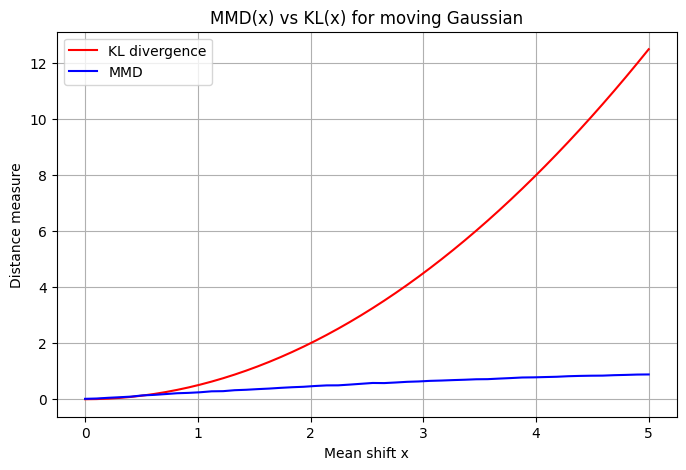

In [33]:
xs = torch.linspace(0, 5, 50)
kl_values = []
mmd_values = []

for x in xs:
    p = centered_gaussian(2000)
    q = moving_gaussian(2000, mean_shift=x.item())
    kl_values.append(kl_gaussian(x))
    mmd_values.append(compute_mmd(p, q))

kl_values = torch.tensor(kl_values)
mmd_values = torch.tensor(mmd_values)

# Ploting
plt.figure(figsize=(8,5))
plt.plot(xs, kl_values, label="KL divergence", color="red")
plt.plot(xs, mmd_values, label="MMD", color="blue")
plt.xlabel("Mean shift x")
plt.ylabel("Distance measure")
plt.title("MMD(x) vs KL(x) for moving Gaussian")
plt.legend()
plt.grid(True)
plt.show()


> The KL divergence keeps increasing as the moving Gaussian shifts further from the center, reflecting an unbounded measure of dissimilarity.
> The MMD, however, increases only until the distributions are far enough that their samples no longer overlap under the chosen kernel beyond that, MMD saturates, showing that it captures *local* similarity rather than absolute separation.

## Bonus: KL vs MMD for generated vs real samples

Compare a **non-pretrained** tiny generator vs real MNIST distribution using KL and MMD.


In [ ]:
class TinyGen(nn.Module):
    """A very small, untrained generator for demonstration purposes.
       zdim: dimension of the input noise vector
    """

    def __init__(self, zdim=64):
        super().__init__()
        self.zdim = zdim
        self.net =
    def forward(self, n=512):
        return self.net(z)

# -------- Real samples from MNIST (assumes mnist_train exists) --------
@torch.no_grad()
def sample_real_images(n=512):
    idx = torch.randperm(len(mnist_train))[:n]
    xs = torch.stack([mnist_train[i][0] for i in idx], dim=0)  # [n,1,28,28], in [0,1]
    return xs.to(device)

# -------- KL & MMD utilities --------
def kl_discrete(p_hist, q_hist, eps=0.0):
    p = p_hist.astype(np.float64)
    q = q_hist.astype(np.float64)
    if eps > 0:
        #smoothed version

    else:
       #raw version
    return

@torch.no_grad()
def mmd_images(x_real, x_fake, sigmas=(5,10,20)):
    #compute MMD between two image sets
    return

# -------- Run once (non-pretrained) --------
gen_bad = TinyGen().to(device).eval()
real = sample_real_images(512)
fake_bad = gen_bad(512).clamp(0,1)

bins = np.linspace(0, 1, 257)
ph, _ = np.histogram(real.detach().cpu().numpy().ravel(), bins=bins)
qh_bad, _ = np.histogram(fake_bad.detach().cpu().numpy().ravel(), bins=bins)  # <-- detach!

kl_raw_bad = kl_discrete(ph, qh_bad, eps=0.0)
kl_smooth_bad = kl_discrete(ph, qh_bad, eps=1e-8)
mmd_bad = mmd_images(real, fake_bad)

print("Non-pretrained generator vs real:")
print(f"  KL (raw)     : {kl_raw_bad}")
print(f"  KL (smoothed): {kl_smooth_bad:.3f}")
print(f"  MMD          : {mmd_bad:.3f}")

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# -------- A tiny discriminator (CNN) --------
class TinyDisc(nn.Module):
    def __init__(self):
        super().__init__()
        self.net =

    def forward(self, x):
        return

# -------- Instantiate G and D --------
gen = TinyGen().to(device)
disc = TinyDisc().to(device)

optG = torch.optim.Adam(gen.parameters(),  lr=2e-4, betas=(0.5, 0.999))
optD = torch.optim.Adam(disc.parameters(), lr=2e-4, betas=(0.5, 0.999))
bce  = nn.BCEWithLogitsLoss()

# -------- Metrics setup --------
EPOCHS = 60
BATCH  = 256
KL_raw, KL_smooth, MMD_vals, G_losses, D_losses = [], [], [], [], []

# Fix a reference real batch (for consistent KL/MMD across epochs)
with torch.no_grad():
    real_ref = sample_real_images(512)                                 # [512,1,28,28]
bins = np.linspace(0, 1, 257)
ph_ref, _ = np.histogram(real_ref.detach().cpu().numpy().ravel(), bins=bins)

for epoch in range(1, EPOCHS+1):
    # -----------------------
    # 1) Train Discriminator
    # -----------------------

    # -----------------------
    # 2) Train Generator
    # -----------------------

    # -----------------------
    # 3) Metrics (KL / MMD)
    # -----------------------

# -----------------------
# 4) Plots
# -----------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# (a) KL
axes[0].plot(range(1, EPOCHS+1), KL_raw, 'o-', label='KL (raw)')
axes[0].plot(range(1, EPOCHS+1), KL_smooth, 'o--', label='KL (smoothed)')
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("KL"); axes[0].set_title("KL vs Epoch")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# (b) MMD
axes[1].plot(range(1, EPOCHS+1), MMD_vals, 'o-', color='teal', label='MMD')
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MMD"); axes[1].set_title("MMD vs Epoch")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# (c) GAN losses
axes[2].plot(range(1, EPOCHS+1), D_losses, '-', label='D loss')
axes[2].plot(range(1, EPOCHS+1), G_losses, '-', label='G loss')
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Loss"); axes[2].set_title("GAN Losses")
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

> Question: What we can conclude about this results in this toy experiment? How does it affect real GAN training?